# Airbnb Pricing Analysis — European Cities
## Exploratory Data Analysis (EDA) with Python

This notebook explores the cleaned Airbnb dataset to identify pricing patterns,
geographic trends, and key factors that influence listing prices across 10 European cities.

**Dataset:** `airbnb_clean.csv` — 51,571 listings · 10 cities · 21 columns

> 🗒️ **Note:** Run `Data_Cleaning_Airbnb.ipynb` first to generate the `airbnb_clean.csv` file.

## 1. Mount Google Drive
We mount Google Drive to access the dataset files stored in the cloud.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import Libraries

We import the libraries needed for data manipulation and visualization.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 3. Load Data

We load the cleaned dataset generated in `Data_Cleaning_Airbnb.ipynb`.

In [14]:
FOLDER = '/content/drive/MyDrive/Portfolio/Project3-Airbnb/Dataset/'

df = pd.read_csv(FOLDER + 'airbnb_clean.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (51571, 21)


,city,day_type,room_type,is_shared_room,is_private_room,is_superhost,host_has_multiple_listings,host_is_business,person_capacity,bedrooms,...,price,price_per_night,cleanliness_rating,overall_rating,dist_to_center_km,dist_to_metro_km,attraction_index,restaurant_index,longitude,latitude
0,Amsterdam,Weekend,Private room,0,1,0,0,1,2,1,...,319.640053,79.91,9.0,88.0,4.763360,0.852117,5.871971,11.941560,4.85,52.34
1,Amsterdam,Weekend,Private room,0,1,0,0,1,2,1,...,347.995219,87.00,9.0,87.0,5.748310,3.651591,3.985516,8.315410,4.98,52.36
2,Amsterdam,Weekend,Private room,0,1,0,0,1,4,2,...,482.975183,120.74,9.0,90.0,0.384872,0.439852,26.116521,76.289005,4.89,52.38
3,Amsterdam,Weekend,Private room,0,1,1,0,0,2,1,...,485.552926,121.39,10.0,98.0,0.544723,0.318688,29.270850,71.074937,4.90,52.38
4,Amsterdam,Weekend,Entire home/apt,0,0,0,0,0,4,2,...,1001.804420,250.45,9.0,96.0,3.719139,1.196104,5.624209,11.670800,4.86,52.40


## 4. Price Analysis

### 4.1 Price Distribution

We analyze how prices are distributed across all listings.

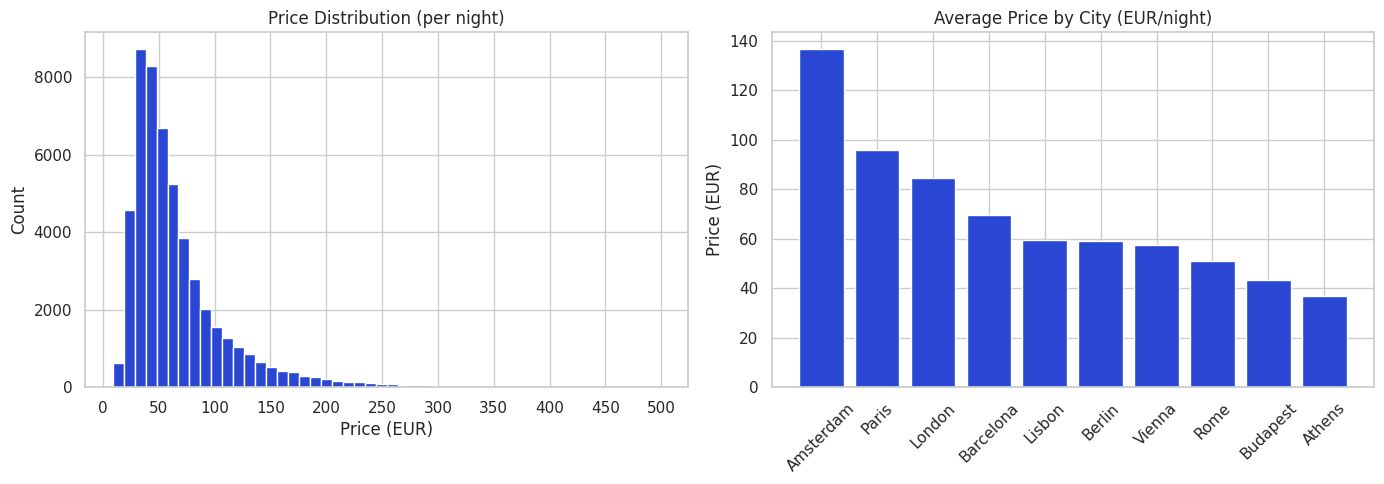

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price_per_night'], bins=50, color='#2947d3', edgecolor='white')
axes[0].set_title('Price Distribution (per night)')
axes[0].set_xlabel('Price (EUR)')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 501, 50))

# Average price by city
city_avg = df.groupby('city')['price_per_night'].mean().sort_values(ascending=False)
axes[1].bar(city_avg.index, city_avg.values, color='#2947d3')
axes[1].set_title('Average Price by City (EUR/night)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Price (EUR)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.2 Price by Room Type

We compare average prices across different room types.

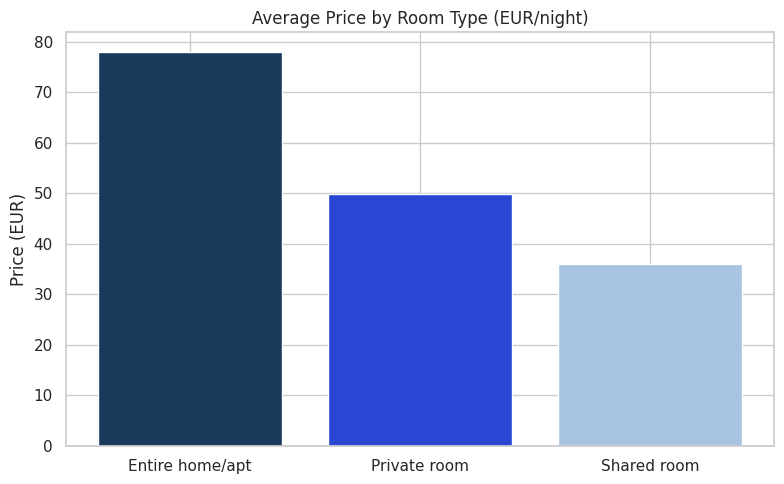

In [35]:
room_avg = df.groupby('room_type')['price_per_night'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(room_avg.index, room_avg.values, color=['#1a3a5c', '#2947d3', '#a8c4e0'])
plt.title('Average Price by Room Type (EUR/night)')
plt.xlabel('')
plt.ylabel('Price (EUR)')
plt.tight_layout()
plt.show()

### 4.3 Price by Day Type

We compare average prices between weekdays and weekends.

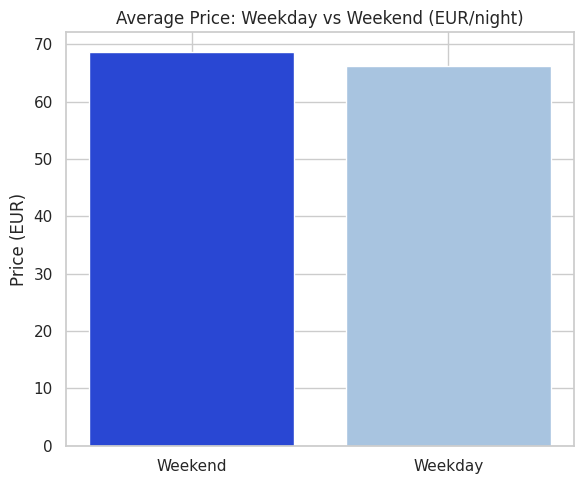

In [23]:
day_avg = df.groupby('day_type')['price_per_night'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 5))
plt.bar(day_avg.index, day_avg.values, color=['#2947d3', '#a8c4e0'])
plt.title('Average Price: Weekday vs Weekend (EUR/night)')
plt.xlabel('')
plt.ylabel('Price (EUR)')
plt.tight_layout()
plt.show()

### 4.4 Price vs Distance to City Center

We analyze whether listings closer to the city center are more expensive.

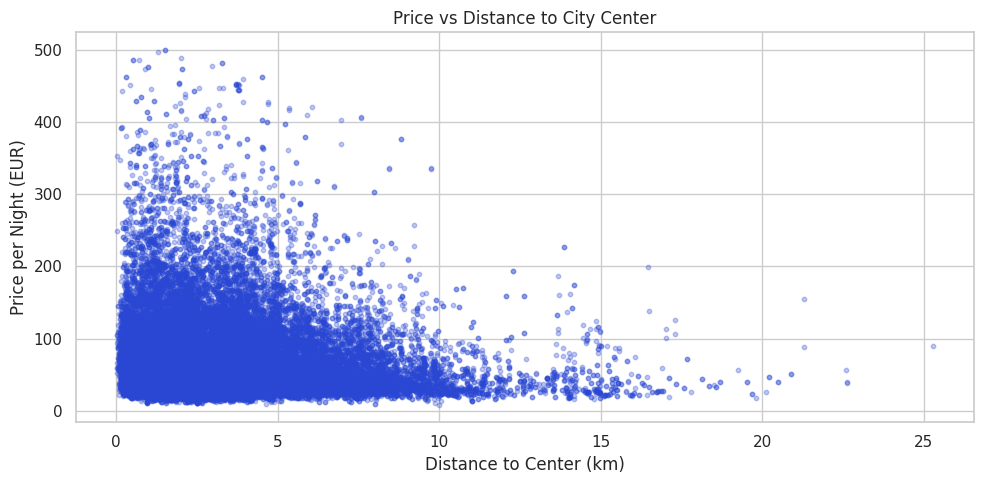

In [25]:
plt.figure(figsize=(10, 5))
plt.scatter(df['dist_to_center_km'], df['price_per_night'],
            alpha=0.3, color='#2947d3', s=10)
plt.title('Price vs Distance to City Center')
plt.xlabel('Distance to Center (km)')
plt.ylabel('Price per Night (EUR)')
plt.tight_layout()
plt.show()

### 4.5 Superhost vs Non-Superhost Prices

We compare average prices between superhosts and regular hosts.

A Superhost is a host recognized by Airbnb for consistently excellent reviews,
high response rates, and low cancellation rates.

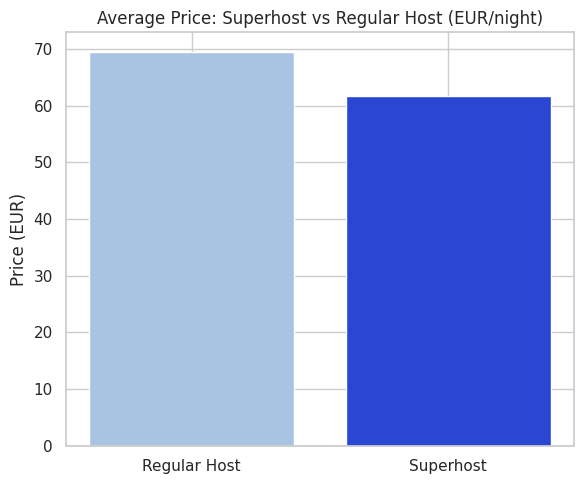

In [26]:
superhost_avg = df.groupby('is_superhost')['price_per_night'].mean()
superhost_avg.index = ['Regular Host', 'Superhost']

plt.figure(figsize=(6, 5))
plt.bar(superhost_avg.index, superhost_avg.values, color=['#a8c4e0', '#2947d3'])
plt.title('Average Price: Superhost vs Regular Host (EUR/night)')
plt.xlabel('')
plt.ylabel('Price (EUR)')
plt.tight_layout()
plt.show()

### 4.6 Price by City and Day Type

We analyze whether the weekday/weekend price difference varies by city.

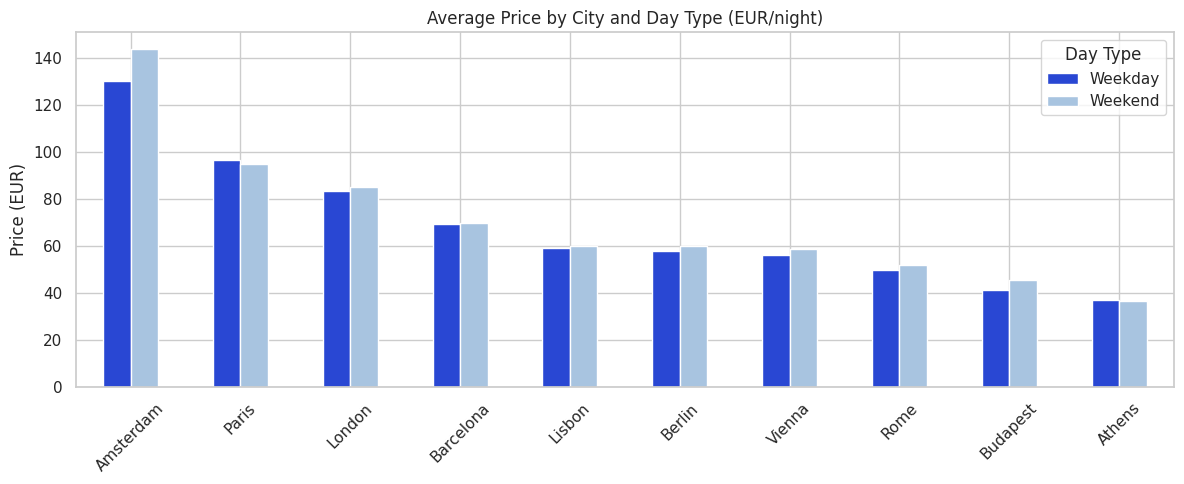

In [29]:
city_day = df.groupby(['city', 'day_type'])['price_per_night'].mean().unstack()
city_day = city_day.loc[city_day.mean(axis=1).sort_values(ascending=False).index]

city_day.plot(kind='bar', figsize=(12, 5), color=['#2947d3', '#a8c4e0'])
plt.title('Average Price by City and Day Type (EUR/night)')
plt.xlabel('')
plt.ylabel('Price (EUR)')
plt.xticks(rotation=45)
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

## 5. Geographic Analysis

In this section we explore how location influences listing availability and pricing patterns across the 10 European cities.

### 5.1 Listings by City

We analyze how many listings each city has in the dataset.

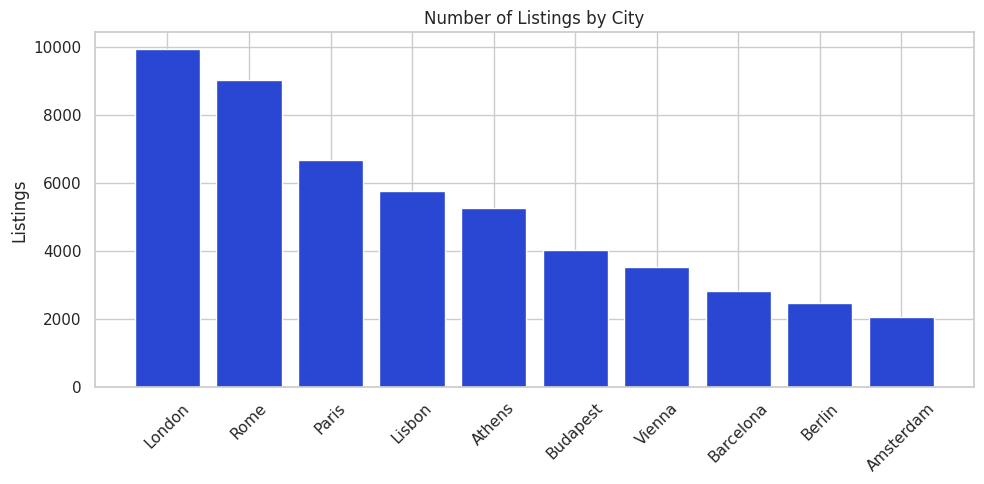

In [33]:
city_count = df['city'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(city_count.index, city_count.values, color='#2947d3')
plt.title('Number of Listings by City')
plt.xlabel('')
plt.ylabel('Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.2 Room Type Distribution by City

We analyze what types of accommodation are most common in each city.

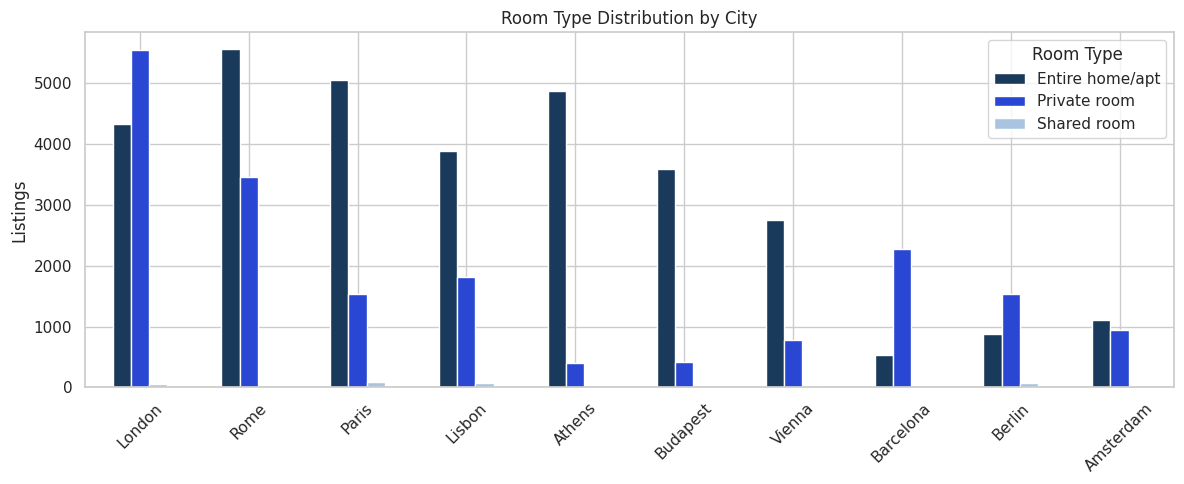

In [34]:
room_city = df.groupby(['city', 'room_type']).size().unstack()
room_city = room_city.loc[room_city.sum(axis=1).sort_values(ascending=False).index]

room_city.plot(kind='bar', figsize=(12, 5), color=['#1a3a5c', '#2947d3', '#a8c4e0'])
plt.title('Room Type Distribution by City')
plt.xlabel('')
plt.ylabel('Listings')
plt.xticks(rotation=45)
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

### 5.3 Average Overall Rating by City

We identify which cities have the highest guest satisfaction scores.

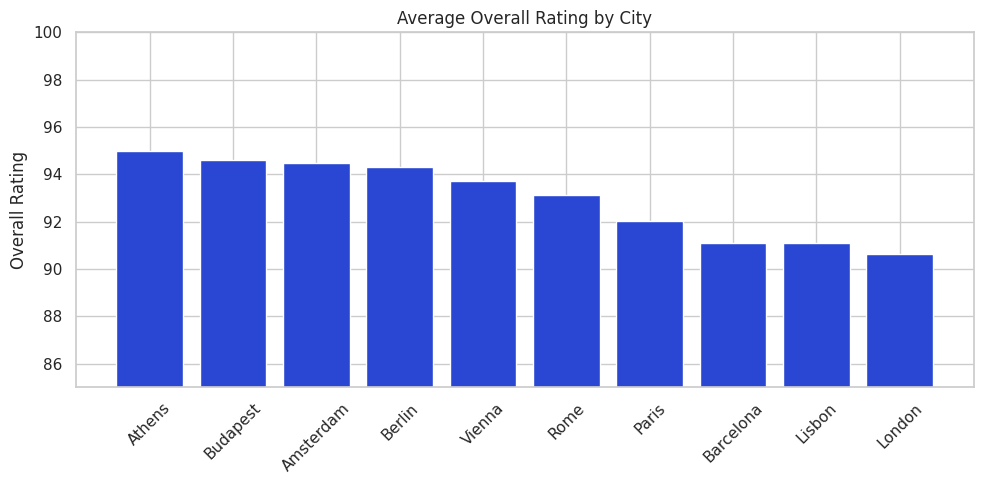

In [38]:
rating_city = df.groupby('city')['overall_rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(rating_city.index, rating_city.values, color='#2947d3')
plt.title('Average Overall Rating by City')
plt.xlabel('')
plt.ylabel('Overall Rating')
plt.xticks(rotation=45)
plt.ylim(85, 100)
plt.tight_layout()
plt.show()

## 6. Host Analysis

In this section we explore how host characteristics influence pricing and availability.

### 6.1 Average Price by Host Type

We compare pricing across different host profiles — regular hosts, superhosts, and business hosts.

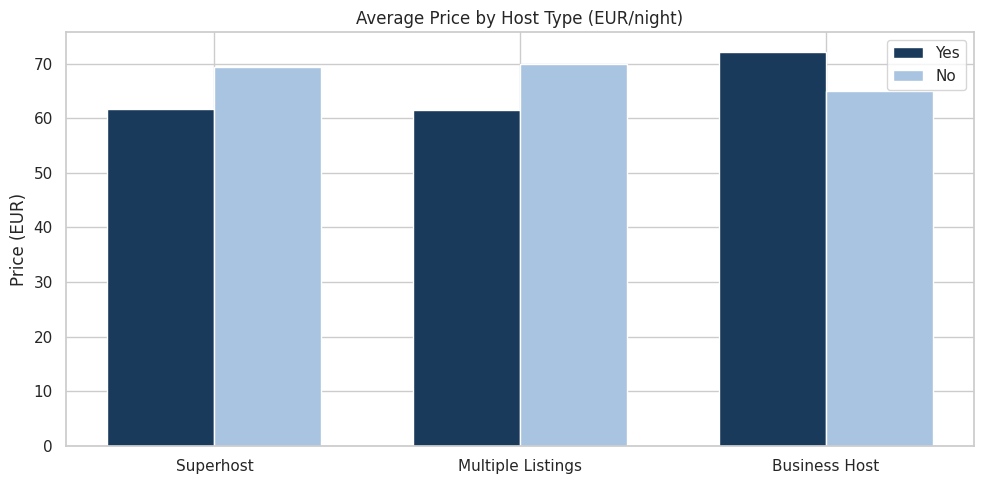

In [40]:
host_cols = ['is_superhost', 'host_has_multiple_listings', 'host_is_business']
labels = ['Superhost', 'Multiple Listings', 'Business Host']

avg_prices = [df[df[col] == 1]['price_per_night'].mean() for col in host_cols]
avg_prices_no = [df[df[col] == 0]['price_per_night'].mean() for col in host_cols]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], avg_prices, width, label='Yes', color='#1a3a5c')
ax.bar([i + width/2 for i in x], avg_prices_no, width, label='No', color='#a8c4e0')
ax.set_title('Average Price by Host Type (EUR/night)')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Price (EUR)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Listings by Person Capacity

We analyze how person capacity is distributed across listings, and whether higher-capacity listings command higher prices.

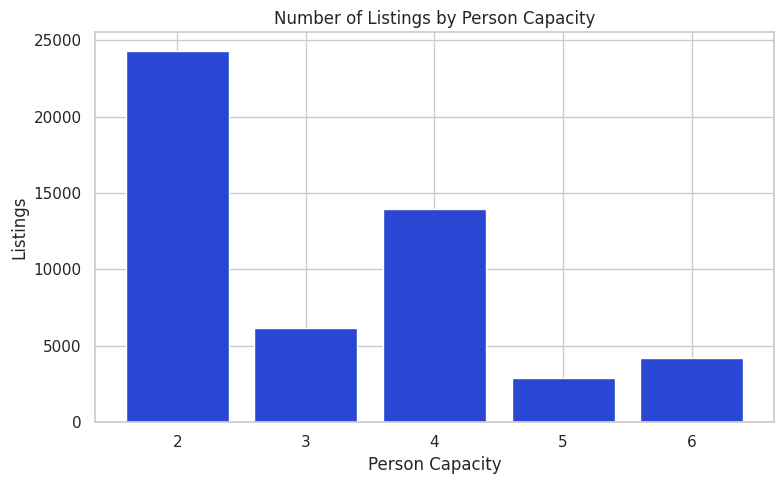

In [41]:
capacity_count = df['person_capacity'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(capacity_count.index, capacity_count.values, color='#2947d3')
plt.title('Number of Listings by Person Capacity')
plt.xlabel('Person Capacity')
plt.ylabel('Listings')
plt.tight_layout()
plt.show()

## 7. Conclusions

### Key Findings

**Pricing**
- Amsterdam and London are the most expensive cities on average, with Paris and Vienna following closely.
- Entire homes/apartments are significantly more expensive than private or shared rooms across all cities.
- Weekend prices are slightly higher than weekday prices, with the gap most visible in tourist-heavy cities.
- Price does not increase significantly with higher guest ratings — quality alone does not justify a premium.

**Geography**
- London has the highest number of listings in the dataset, followed by Paris and Rome.
- Athens, Budapest, and Vienna have the fewest listings, suggesting less market saturation and potential opportunity.
- Entire home/apt is the dominant room type in most cities, reflecting guest preference for privacy.
- Listings closer to the city center tend to be priced higher, though the relationship is not strictly linear.

**Hosts**
- Superhosts do not necessarily charge higher prices than regular hosts — their advantage is trust, not price.
- Business hosts tend to have slightly higher average prices, likely due to more professional setups.
- Hosts with multiple listings show pricing patterns similar to single-listing hosts.

**Capacity**
- Most listings accommodate 2 to 4 people, aligning with the dataset's target of couples and small groups.
- Larger-capacity listings (5+) are less frequent but tend to command higher total prices.